# RT
Load RT data and clean it step by step.

In [33]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")


def load_rt_data() -> tuple[pd.DataFrame, Path]:
    project_root = resolve_project_root()
    rt_file = project_root / "data" / "raw" / "Alternative Medien" / "RT_de.xlsx"

    frame = pd.read_excel(rt_file)
    frame["source"] = "RT_de"
    frame["source_file"] = rt_file.name
    return frame, rt_file


df, rt_file = load_rt_data()
df_clean = df.copy()


In [34]:
df_clean = df_clean.drop(columns=["Full_Text"], errors="ignore")
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow\n\nDie Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx
...,...,...,...,...,...,...,...,...
12385,2024-11-14,Hauptseite\n/\nSchweiz,Gedemütigt und geschlagen: Was Prostituierte in der Schweiz durchmachen,"Die Realität von Sexarbeiterinnen in der Schweiz bleibt auch heute noch erschreckend: Gewalt, Diskriminierung und sexuelle Übergriffe gehören zum Alltag vie...","Eine aktuelle Studie der Schweizer Organisation ProCoRe verdeutlicht die prekären Umstände, denen diese Frauen ausgesetzt sind.\n\nDie Befragung, die 24 Fra...",https://freedert.online/schweiz/225947-geschlagen-und-gedemuetigt-was-prostituierte/,RT_de,RT_de.xlsx
12386,2024-11-14,Hauptseite\n/\nUkraine-Krieg,Bloomberg: Ukrainer spenden immer weniger für ihre Streitkräfte,"Ukrainische Stiftungen, die die Armee unterstützen, melden starke Rückgänge der Spenden. Angesichts der wirtschaftlichen Schwierigkeiten, Kriegsmüdigkeit un...","Die Bereitschaft der Ukrainer, zur Verteidigung des Landes beizutragen, hat nachgelassen, berichtet die Nachrichtenagentur Bloomberg. Angesichts der Wirtsch...",https://freedert.online/europa/225884-bloomberg-ukrainer-spenden-immer-weniger/,RT_de,RT_de.xlsx
12387,2024-11-14,Hauptseite\n/\nÖsterreich,Österreich: Traditionsmarke Kika/Leiner vor dem Aus,"Ein bitteres Ende für den österreichischen

In [35]:
from IPython.display import display

pd.set_option("display.max_colwidth", 160)

def clean_rt_text_column(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    cleaned["Text"] = (
        cleaned["Text"]
        .astype("string")
        .fillna("")
        .str.replace(r"(?s)\n*\s*Mehr zum Thema.*$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return cleaned


df_clean = clean_rt_text_column(df_clean)

print(f"Loaded {len(df_clean):,} rows from {rt_file}")


Loaded 12,390 rows from /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/RT_de.xlsx


In [36]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
Text,0,0.000000
URL,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [37]:
# filter df_clean to Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"

df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = df_clean["Date"].between(start, end, inclusive="both")

df_clean = df_clean.loc[mask].copy()



In [38]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 0 to 4569
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4570 non-null   datetime64[ns]
 1   Category     4570 non-null   object        
 2   Title        4570 non-null   object        
 3   Summary      4567 non-null   object        
 4   Text         4570 non-null   string        
 5   URL          4570 non-null   object        
 6   source       4570 non-null   object        
 7   source_file  4570 non-null   object        
dtypes: datetime64[ns](1), object(6), string(1)
memory usage: 321.3+ KB


In [39]:
# Text column already created in the dedicated cleaning cell
df_clean["Text"] = df_clean["Text"].astype("string")


Removal of "Mehr zum Thema"

In [40]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Text"] = df_clean["Text"].apply(remove_mehr_zum_thema)


In [41]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [42]:
#!pip install seaborn


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    4570.0
mean      582.3
std       410.2
min         0.0
10%       249.9
25%       313.0
50%       421.0
75%       709.8
90%      1208.1
95%      1450.6
99%      1958.0
max      3867.0
Name: article_length_words, dtype: float64

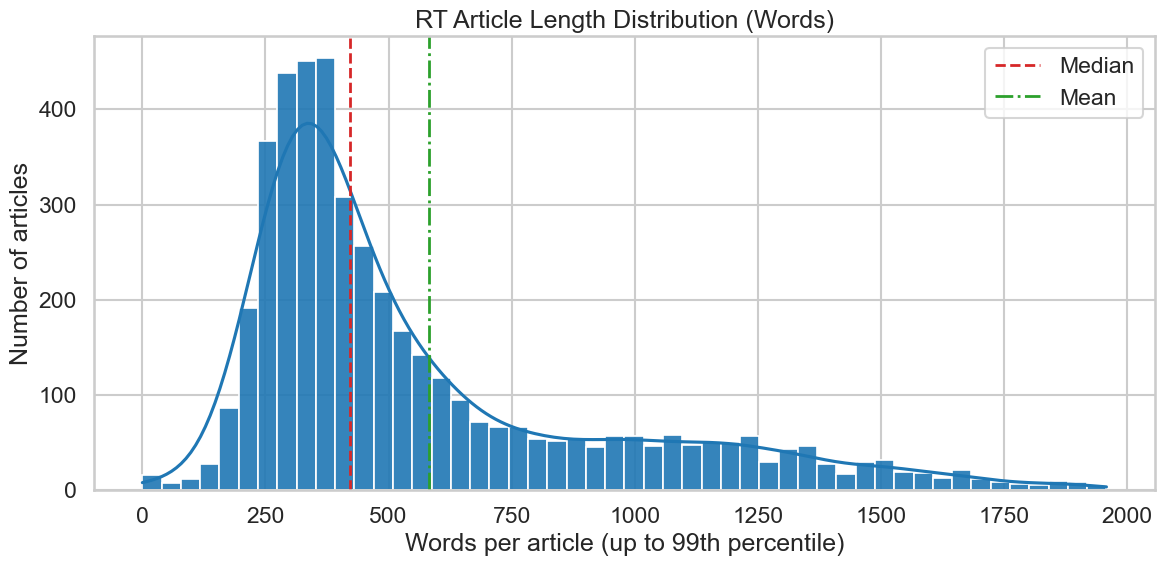

In [45]:
# Plot article length distribution, excluding extreme outliers above the 99th percentile
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


In [46]:
# Compute daily article counts and 7-day rolling average
daily_counts = (
    df_clean.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()


,Date,articles,rolling_7d
0,2025-08-01,15,15.000000
1,2025-08-02,28,21.500000
2,2025-08-03,24,22.333333
3,2025-08-04,26,23.250000
4,2025-08-05,32,25.000000


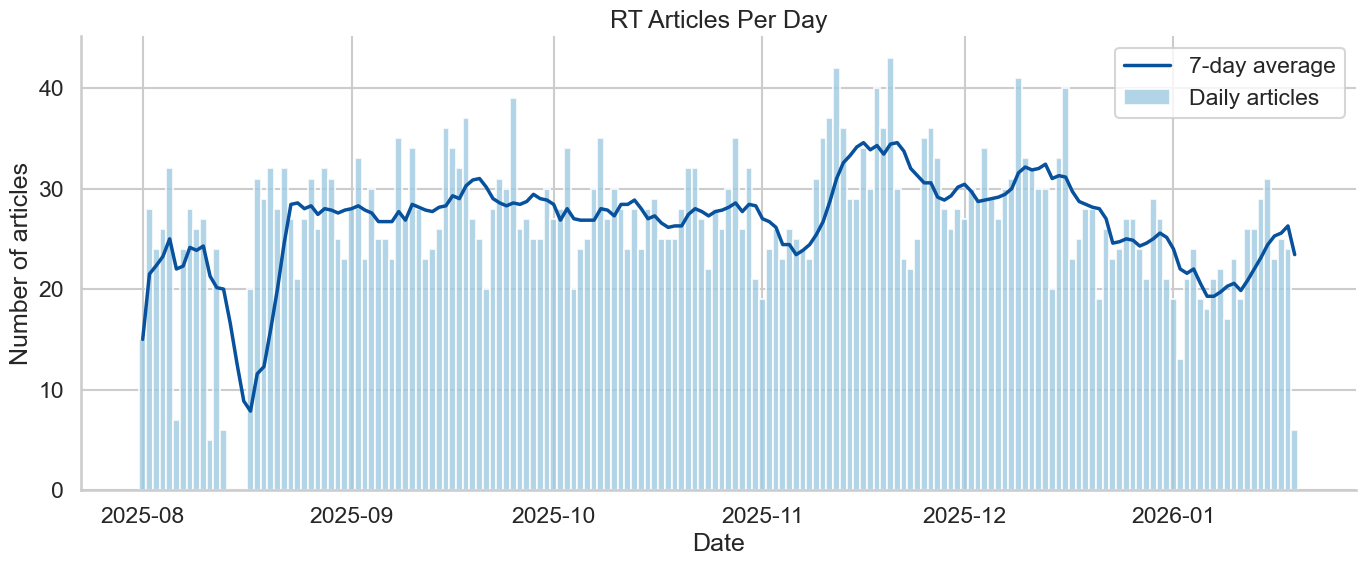

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## BERTopic old 


In [48]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [49]:
from BERTopic.bertopic_config import BERTopicConfig, title_config
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [50]:
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file,article_length_words,article_length_chars
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx,280,1979
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx,423,3091
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx,418,3211
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx,329,2534
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx,965,6979
...,...,...,...,...,...,...,...,...,...,...
4565,2025-08-01,Hauptseite\n/\nInternational,EU-Gericht erhöht Hürden zur Einstufung sicherer Herkunftsländer,EU-Gericht hat die Hürden bei der Bestimmung von sicheren Herkunftsländern für beschleunigte Asylverfahren erhöht. Nur wenn die EU-Mitgliedstaaten die Quell...,Der Europäische Gerichtshof (EuGH) hat die Hürden für die Bestimmung von sicheren Herkunftsländern für beschleunigte Asylverfahren erhöht. Laut dem Gericht ...,https://freedert.online/europa/252162-eu-gericht-erhoeht-huerden-zur/,RT_de,RT_de.xlsx,276,2118
4566,2025-08-01,Hauptseite\n/\nDeutschland,Bundestagspräsidentin Klöckner in Genf: Diplomatie als Mittel zur moralischer Empörung,"Als die Sprecherin des russischen Föderationsrates auf einer internationalen Versammlung in Genf eine Rede hielt, verließ Bundestagspräsidentin Klöckner den...","Von Gert Ewen Ungar In Genf findet seit dem Jahr 2000 alle fünf Jahre das internationale Treffen der Parlamentssprecher statt, das von der Internationalen P...",https://freedert.online/meinung/252106-bundestagspraesidentin-kloeckner-in-genf-diplomatie/,RT_de,RT_de.xlsx,801,5867
4567,2025-08-0

In [68]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AttributeError: 'BERTopicConfig' object has no attribute 'spacy_model_name'

In [63]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1730,-1_soldaten_afd_bundeswehr_macron,"[soldaten, afd, bundeswehr, macron, grönland, ungarn, kirk, leyen, ukrainer, litauen]","[Von Felicitas Rabe Im Interview erklärt der Kölner Publizist Dr. Werner Rügemer, wie die USA zunächst unter Konrad Adenauer, später bei der Übernahme der D..."
1,0,317,0_gaza_hamas_israelischen_iran,"[gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels, iranische]","[Der israelische Ministerpräsident Benjamin Netanjahu wies laut Medien die Armee an, die Luftangriffe im Gazastreifen wieder zu intensivieren. Israels Verte..."
2,1,308,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, nicolás maduro, nicolás, drogen, öl, lateinamerika]",[Die USA haben nach eigenen Angaben ein aus Venezuela kommendes Boot angegriffen und zerstört. Dabei starben elf Menschen. Laut US-Angaben soll es sich dabe...
3,2,295,2_flugzeuge_luftraum_flugzeug_ukrainischen streitkräfte,"[flugzeuge, luftraum, flugzeug, ukrainischen streitkräfte, drohne, schiff, kilometer, tanker, verteidigungsministerium, soldaten]",[Von Jewgeni Krutikow Russlands Truppen haben das kleine Dorf Olgowskoje im Gebiet Saporoschje im Sturm eingenommen und sind dadurch in unmittelbaren Kontak...
4,3,262,3_afd_spd_cdu_bsw,"[afd, spd, cdu, bsw, grünen, weidel, demokratie, kandidaten, fraktion, koalition]","[Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Westfalens Stichwahlen um die Posten von Landrats-, Bürgermeister- und Oberbürgermeister-Äm..."
5,4,257,4_bundesregierung_kinder_afghanen_ukrainer,"[bundesregierung, kinder, afghanen, ukrainer, männer, spd, industrie, junge, cdu, armut]","[Von Alexandra Nollok Weihnachten ist vorbei, und die karitativen Selbstdarsteller, die Obdachlose mit gespendeten Schlafsäcken, Socken und Festessen beglüc..."
6,5,225,5_alaska_lawrow_treffens_putin trump,"[alaska, lawrow, treffens, putin trump, wladimir selenskij, uschakow, weißen haus, staatschefs, budapest, gipfeltreffen]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
7,6,165,6_peking_taiwan_chinas_chinesischen,"[peking, taiwan, chinas, chinesischen, chinesische, japan, xi, südkorea, zölle, insel]","[China hat seinen neuen Flugzeugträger ""Fujian"" offiziell in Dienst gestellt. Bei der Zeremonie auf der Insel Hainan nahm Staats- und Parteichef Xi Jinping ..."
8,7,136,7_öl_barrel_gas_tonnen,"[öl, barrel, gas, tonnen, millionen tonnen, dollar pro, russischem, lieferungen, visa, preise]","[Von Olga Samofalowa Der Preis für die führende russische Erdölsorte Urals ist auf 34 US-Dollar pro Barrel gefallen. Selbst im Jahr 2020, als die Welt von e..."
9,8,101,8_belgien_gelder_eingefrorenen_russischer vermögenswerte,"[belgien, gelder, eingefrorenen, russischer vermögenswerte, wever, de wever, zentralbank, russische vermögenswerte, eingefrorenen russischen, vermögen]","[Belgiens Premierminister Bart De Wever hat sich entschieden gegen den aktuellen Vorschlag von Bundeskanzler Friedrich Merz ausgesprochen, der der Ukraine e..."


In [65]:
rt_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)


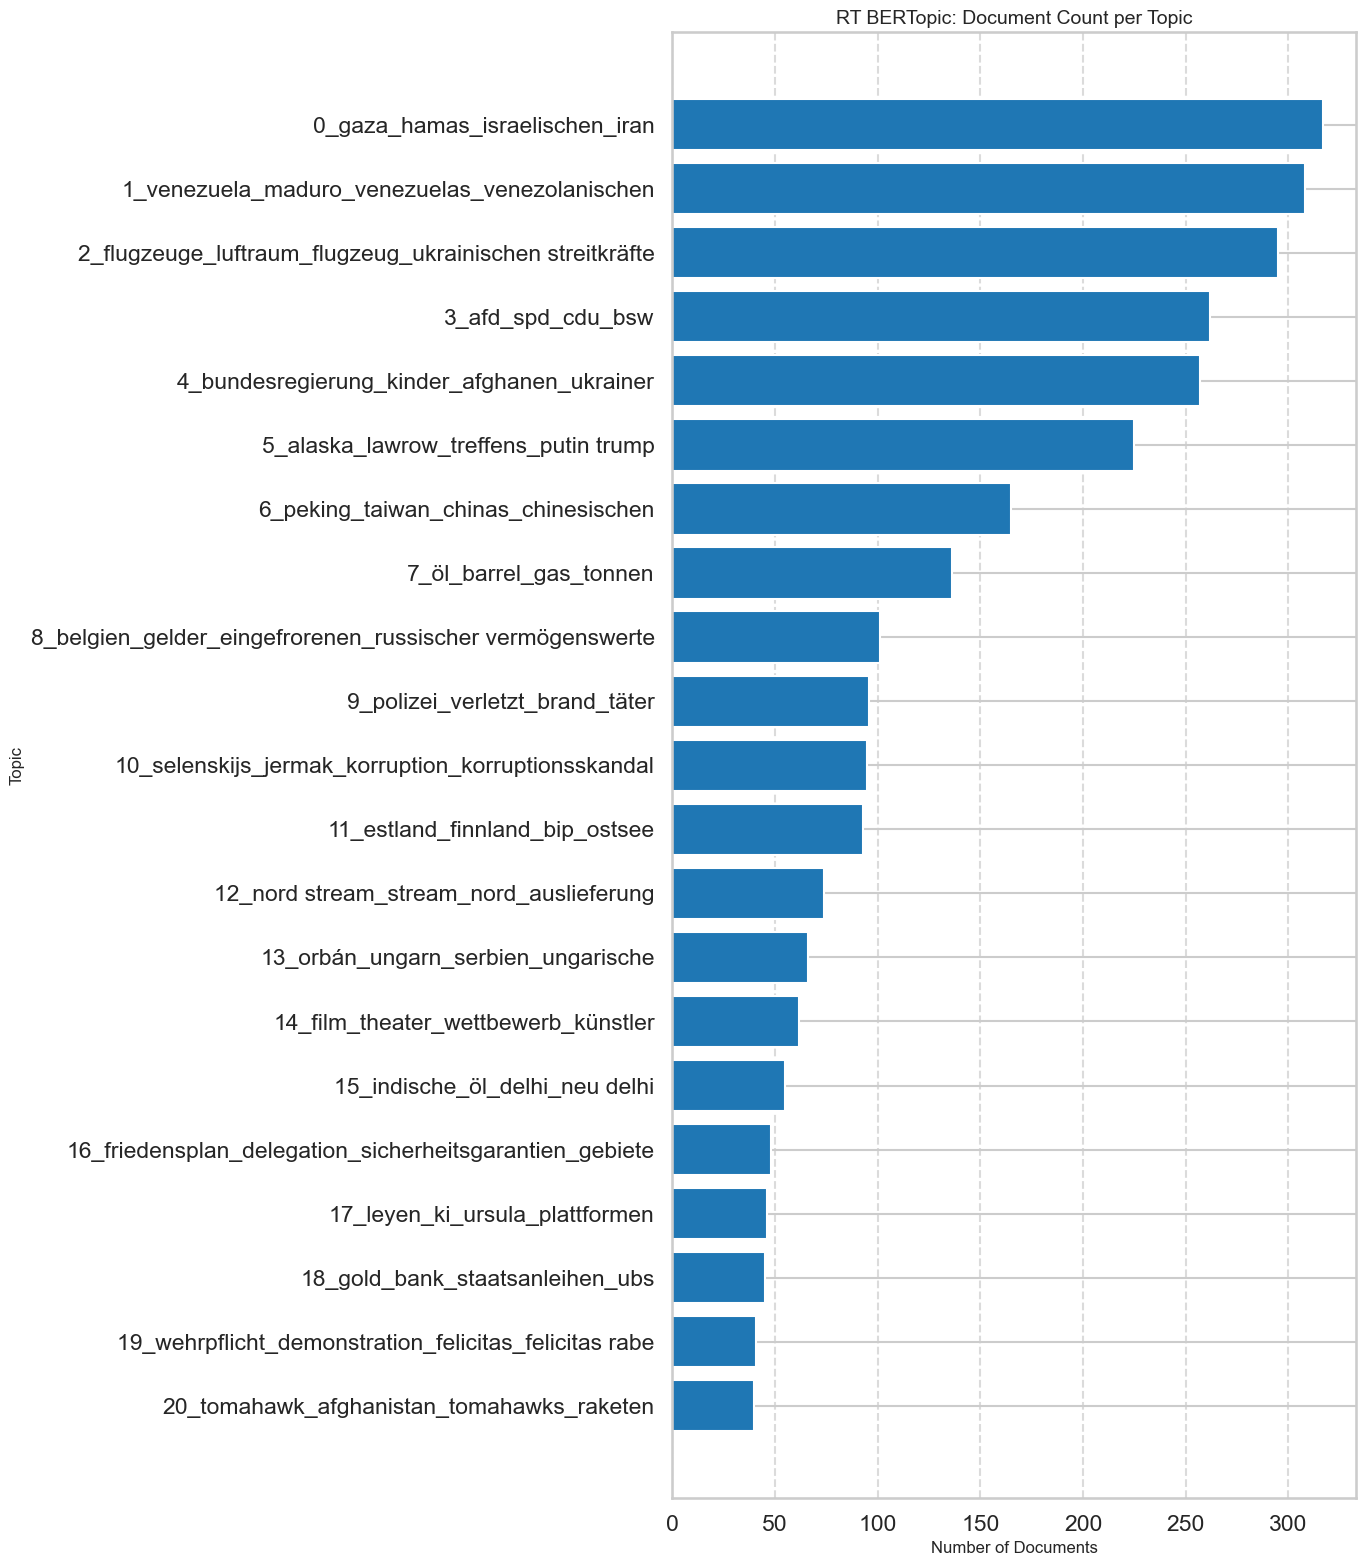

In [66]:
fig, ax = plt.subplots(figsize=(14, 16))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('RT BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
# # Final BERTopic comparison table: all topics + representative words
# from IPython.display import display

# topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

# def _representative_words_for_topic(topic_id: int) -> str:
#     terms = result["topic_model"].get_topic(int(topic_id)) or []
#     return ", ".join(word for word, _ in terms)

# topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
# topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

# with pd.option_context("display.max_colwidth", None, "display.width", 220):
#     display(topics_comparison_df)


In [58]:
# # BERTopic v2 run: full text first, then title-only
# from BERTopic.bertopic_pipelinev2 import (
#     BERTopicV2Config,
#     BERTopicV2ConfigTitle,
#     run_bertopic_pipeline,
# )

# result_full_text_v2 = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Full_Text",
#     config=BERTopicV2Config(),
#     id_col="URL",
#     source_name="RT_de",
# )

# result_title_v2 = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Title",
#     config=BERTopicV2ConfigTitle(),
#     id_col="URL",
#     source_name="RT_de",
# )

# print(
#     f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
#     f"v2 title docs: {len(result_title_v2['docs']):,}"
# )



## BERTopic V2 Text

In [59]:
#!python -m spacy download de_core_news_md


In [60]:
# import sys
# !{sys.executable} -m pip install -U "spacy>=3.8.5" "pydantic>=2.10" "thinc>=8.3.5" "typing_extensions>=4.12"
# !{sys.executable} -m spacy download de_core_news_md


In [61]:
import sys, spacy, pydantic
print(sys.executable)
print("spacy", spacy.__version__, "pydantic", pydantic.__version__)
spacy.load("de_core_news_md")
print("spaCy model loads OK")


/opt/anaconda3/bin/python
spacy 3.8.11 pydantic 2.12.5
spaCy model loads OK


In [62]:
# BERTopic v2 run: full text first, then title-only
# make sure the project root is on sys.path so local modules can be found
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# preferred import when BERTopic is a package folder in your project
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)


result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicV2Config(),
    id_col="URL",
    source_name="RT_de",
)



print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ModuleNotFoundError: In order to use Part of Speech with Spacy you will need to install via;

pip install bertopic[spacy]



In [ ]:
# Build a BERTopic results table with representative words for each topic
topic_info_v2 = result_full_text_v2["topic_info"].copy()
topic_model_v2 = result_full_text_v2["topic_model"]

def get_representative_words(topic_id: int, top_n: int = 10) -> str:
    topic_id = int(topic_id)
    if topic_id == -1:
        return "Outliers"
    terms = topic_model_v2.get_topic(topic_id) or []
    return ", ".join(word for word, _ in terms[:top_n])

base_cols = [c for c in ["Topic", "Count", "Name"] if c in topic_info_v2.columns]
topic_results_table = topic_info_v2[base_cols].copy()
topic_results_table["Representative_Words"] = topic_results_table["Topic"].apply(get_representative_words)
topic_results_table = topic_results_table.sort_values("Topic").reset_index(drop=True)

display(topic_results_table)


## BERTopic V2 Title

In [ ]:
result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=BERTopicV2ConfigTitle(),
    id_col="URL",
    source_name="RT_de",
)

print(
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)
